In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import json as _json
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from matplotlib import pyplot as plt

from cinc.notebook.detection_results import (
    get_structured_participant_data_df,
    apply_matching_processing,
)

tqdm.pandas()

MATTRESS_LABELS_MAP = {
    "h1": "H1",
    "h2": "H2",
    "h3": "H3",
    "h3_sousmatelas": "H3UM",
    "h3_surcouche": "H3OL",
    "h4": "H4",
}

ID_LABELS_MAP = {
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "shanaz": "V6",
    "aurelie": "V7",
    "bastien": "V8",
}

RESPIRATION_CHANNEL = 0

REGULAR_COLOR = '#8da0cb'
QUALITY_COLOR = '#fc8d62'

DF_SAVE_PATH = Path("results.pkl")
DRIFT_ANNOTATIONS_PATH = Path("../data/drift_annotations.json")

## Load Data

In [27]:
structured_participant_data_df = get_structured_participant_data_df()

# Translate mattress labels and remove entries with invalid mattress labels
structured_participant_data_df["mattress"] = (
    structured_participant_data_df["mattress"].map(MATTRESS_LABELS_MAP)
)
structured_participant_data_df = structured_participant_data_df.dropna(subset=["mattress"])

# Translate participant ID labels and remove entries with invalid participant IDs
structured_participant_data_df["id"] = structured_participant_data_df["id"].map(ID_LABELS_MAP)
structured_participant_data_df = structured_participant_data_df.dropna(subset=["id"])

print("Available columns:")
for col in structured_participant_data_df.columns:
    print(f" - {col}")

structured_participant_data_df.head(10)

✅ Found 152 participant files.


⏳ Loading participant data...: 100%|██████████| 152/152 [00:54<00:00,  2.78it/s]


Available columns:
 - id
 - mattress
 - position
 - psg_cardiac_intervals
 - psg_cardiac_signal
 - psg_cardiac_processed_fs
 - psg_cardiac_upsampled_fs
 - pel_cardiac_sensor_intervals_list
 - pel_cardiac_ensemble_intervals
 - pel_cardiac_signal
 - pel_cardiac_signal_length
 - pel_cardiac_processed_fs
 - pel_cardiac_upsampled_fs


,id,mattress,position,psg_cardiac_intervals,psg_cardiac_signal,psg_cardiac_processed_fs,psg_cardiac_upsampled_fs,pel_cardiac_sensor_intervals_list,pel_cardiac_ensemble_intervals,pel_cardiac_signal,pel_cardiac_signal_length,pel_cardiac_processed_fs,pel_cardiac_upsampled_fs
0,V8,H1,left,"[[277, 1181], [1181, 2033], [2033, 2914], [291...","[[11.820937248311282, 19.94207678391439, 26.27...",100.0,1000.0,"[[[2765, 3734], [3734, 4732], [4732, 5683], [5...","[[1131, 1991], [1991, 2874], [2874, 3835], [38...","[[-0.1796263234802899, -0.18143293076218223, -...",18000,100.0,1000.0
1,V8,H1,prone,"[[449, 1225], [1225, 1985], [1985, 2747], [274...","[[7.035296496231743, 32.73891026433242, 34.953...",100.0,1000.0,"[[[330, 1171], [1171, 1933], [1933, 2695], [58...","[[594, 1360], [1360, 2121], [2121, 2884], [288...","[[0.9251551375187665, 0.6528697040294581, 0.37...",18000,100.0,1000.0
2,V8,H1,right,"[[999, 1908], [1908, 2766], [2766, 3607], [360...","[[-12.653744310359777, -2.0588684155143597, -8...",100.0,1000.0,"[[[979, 1883], [1883, 2742], [2742, 3577], [35...","[[1084, 1990], [1990, 2838], [2838, 3687], [36...","[[-0.05175801853100876, -0.11802009234113517, ...",18000,100.0,1000.0
3,V8,H1,supine,"[[677, 1560], [1560, 2476], [2476, 3437], [343...","[[178.60672214753336, 132.42398572284262, 85.0...",100.0,1000.0,"[[[554, 1429], [1429, 2351], [2351, 3324], [33...","[[402, 1285], [1285, 2198], [2198, 3168], [316...","[[0.013257699302005828, 0.004756048187675686, ...",17500,100.0,1000.0
4,V8,H4,left,"[[550, 1649], [1649, 2733], [2733, 3776], [377...","[[-1.524302255252027, -2.3812789710386033, -6....",100.0,1000.0,"[[[636, 1729], [1729, 2805], [2805, 3862], [38...","[[531, 1631], [1631, 2702], [2702, 3751], [375...","[[-0.007429539871858954, -0.02594743610601381,...",18000,100.0,1000.0
5,V8,H4,prone,"[[314, 1247], [1247, 2188], [2188, 3093], [309...","[[14.983368415868181, 6.03891691369866, -1.114...",100.0,1000.0,"[[[327, 1272], [1272, 2223], [2223, 3109], [31...","[[442, 1380], [1380, 2331], [2331, 3218], [321...","[[-0.9121556936409606, -0.705360268339776, -0....",18000,100.0,1000.0
6,V8,H4,right,"[[1097, 2193], [2193, 3306], [3306, 4372], [43...","[[1.6949114039220439, 1.9352613899723607, -0.6...",100.0,1000.0,"[[[8507, 9540], [9540, 10535], [10535, 11538],...","[[1110, 2213], [2213, 3328], [3328, 4389], [43...","[[-0.07068514752616806, -0.025093025122322667,...",18000,100.0,1000.0
7,V8,H4,supine,"[[635, 1706], [1706, 2829], [2829, 3945], [394...","[[5.3307974952493, 16.879219653031782, 41.6494...",100.0,1000.0,"[[[647, 1726], [1726, 2845], [2845, 3953], [39...","[[651, 1723], [1723, 2851], [2851, 3968], [396...","[[0.3185066181304486, 0.309563318960916, 0.287...",18000,100.0,1000.0
8,V1,H1,left,"[[289, 1011], [1011, 1757], [1757, 2520], [252...","[[-15.480615008579651, -11.680180605876574, -1...",100.0,1000.0,"[[[3243, 4049], [4049, 4842], [80965, 81673], ...","[[2921, 3728], [3728, 4528], [4528, 5326], [53...","[[-0.14701358907616852, -0.08176084343573571, ...",18000,100.0,1000.0
9,V1,H1,prone,"[[411, 1178], [1178, 1907], [1907, 2616], [261...","[[12.797846599126672, 30.63289566210703, 38.47...",100.0,1000.0,"[[[854, 1625], [1625, 2361], [2361, 3075], [30...","[[741, 1510], [1510, 2249], [2249, 2962], [296...","[[0.39609802857631304, 1.1164781520050147, 1.9...",18000,100.0,1000.0


## Apply Drift Correction

Load drift annotations produced by `script/annotate_drift.py`.
- **Accepted** recordings: correct PEL interval timing by subtracting the estimated linear drift.
- **Rejected** recordings: removed from the dataframe (unreliable for analysis).

In [28]:
# Load drift annotations
with open(DRIFT_ANNOTATIONS_PATH, encoding="utf-8") as f:
    drift_annotations = _json.load(f)

n_accepted = sum(1 for v in drift_annotations.values() if v.get("accepted"))
n_rejected = sum(1 for v in drift_annotations.values() if not v.get("accepted"))
print(f"Drift annotations: {len(drift_annotations)} total, {n_accepted} accepted, {n_rejected} rejected")


def _recording_key(row):
    return f"{row['id']}_{row['mattress']}_{row['position']}"


def correct_pel_intervals(intervals, drift_rate_ms_per_s, drift_intercept_ms, upsampled_fs):
    """Shift PEL interval indices to compensate for estimated linear drift."""
    if intervals.shape[0] == 0:
        return intervals
    corrected = intervals.astype(float).copy()
    mid_s = (corrected[:, 0] + corrected[:, 1]) / 2.0 / upsampled_fs
    offset_samples = (drift_rate_ms_per_s * mid_s + drift_intercept_ms) / 1000.0 * upsampled_fs
    corrected[:, 0] -= offset_samples
    corrected[:, 1] -= offset_samples
    return np.round(corrected).astype(int)


# Drop rejected recordings and correct accepted ones
rows_to_drop = []
n_corrected = 0
n_no_annotation = 0

for idx, row in structured_participant_data_df.iterrows():
    key = _recording_key(row)
    annotation = drift_annotations.get(key)

    if annotation is None:
        n_no_annotation += 1
        continue

    if not annotation.get("accepted", False):
        rows_to_drop.append(idx)
        continue

    # Apply drift correction to all PEL intervals
    drift_rate = annotation["drift_rate_ms_per_s"]
    drift_intercept = annotation["drift_intercept_ms"]
    fs = row["pel_cardiac_upsampled_fs"]

    # Correct ensemble intervals
    structured_participant_data_df.at[idx, "pel_cardiac_ensemble_intervals"] = correct_pel_intervals(
        row["pel_cardiac_ensemble_intervals"], drift_rate, drift_intercept, fs
    )

    # Correct individual sensor intervals
    corrected_sensors = [
        correct_pel_intervals(sensor_intervals, drift_rate, drift_intercept, fs)
        for sensor_intervals in row["pel_cardiac_sensor_intervals_list"]
    ]
    structured_participant_data_df.at[idx, "pel_cardiac_sensor_intervals_list"] = corrected_sensors
    n_corrected += 1

n_before = len(structured_participant_data_df)
structured_participant_data_df = structured_participant_data_df.drop(rows_to_drop).reset_index(drop=True)
n_after = len(structured_participant_data_df)

print(f"Drift-corrected: {n_corrected} recordings")
print(f"Dropped (rejected drift): {n_before - n_after} recordings ({n_before} -> {n_after})")
if n_no_annotation > 0:
    print(f"Warning: {n_no_annotation} recordings have no drift annotation — kept uncorrected")

Drift annotations: 152 total, 139 accepted, 13 rejected
Drift-corrected: 139 recordings
Dropped (rejected drift): 13 recordings (152 -> 139)


In [29]:
new_structured_participant_data_df = apply_matching_processing(structured_participant_data_df)


print("Available columns:")
for col in new_structured_participant_data_df.columns:
    print(f" - {col}")

new_structured_participant_data_df.head()

Applying interval rate estimation...


100%|██████████| 139/139 [00:00<00:00, 1450.25it/s]


Applying interval matching...


100%|██████████| 139/139 [00:03<00:00, 44.09it/s]


Available columns:
 - id
 - mattress
 - position
 - psg_cardiac_intervals
 - psg_cardiac_signal
 - psg_cardiac_processed_fs
 - psg_cardiac_upsampled_fs
 - pel_cardiac_sensor_intervals_list
 - pel_cardiac_ensemble_intervals
 - pel_cardiac_signal
 - pel_cardiac_signal_length
 - pel_cardiac_processed_fs
 - pel_cardiac_upsampled_fs
 - psg_cardiac_rates
 - pel_cardiac_sensor_rates_list
 - pel_cardiac_ensemble_rates
 - pel_cardiac_sensor_interval_matches_list
 - pel_cardiac_sensor_interval_matchings
 - pel_cardiac_ensemble_interval_matches
 - pel_cardiac_ensemble_interval_matching


,id,mattress,position,psg_cardiac_intervals,psg_cardiac_signal,psg_cardiac_processed_fs,psg_cardiac_upsampled_fs,pel_cardiac_sensor_intervals_list,pel_cardiac_ensemble_intervals,pel_cardiac_signal,pel_cardiac_signal_length,pel_cardiac_processed_fs,pel_cardiac_upsampled_fs,psg_cardiac_rates,pel_cardiac_sensor_rates_list,pel_cardiac_ensemble_rates,pel_cardiac_sensor_interval_matches_list,pel_cardiac_sensor_interval_matchings,pel_cardiac_ensemble_interval_matches,pel_cardiac_ensemble_interval_matching
0,V8,H1,left,"[[277, 1181], [1181, 2033], [2033, 2914], [291...","[[11.820937248311282, 19.94207678391439, 26.27...",100.0,1000.0,"[[[2807, 3776], [3777, 4775], [4775, 5726], [5...","[[1172, 2032], [2033, 2916], [2916, 3877], [38...","[[-0.1796263234802899, -0.18143293076218223, -...",18000,100.0,1000.0,[<cinc.notebook.detection_results.Rate object ...,[[<cinc.notebook.detection_results.Rate object...,[<cinc.notebook.detection_results.Rate object ...,[[{'rate1': <cinc.notebook.detection_results.R...,"[92.57425742574257, 89.10891089108911, 91.5841...",[{'rate1': <cinc.notebook.detection_results.Ra...,99.504950
1,V8,H1,prone,"[[449, 1225], [1225, 1985], [1985, 2747], [274...","[[7.035296496231743, 32.73891026433242, 34.953...",100.0,1000.0,"[[[185, 1026], [1026, 1788], [1788, 2550], [56...","[[449, 1215], [1215, 1976], [1976, 2739], [274...","[[0.9251551375187665, 0.6528697040294581, 0.37...",18000,100.0,1000.0,[<cinc.notebook.detection_results.Rate object ...,[[<cinc.notebook.detection_results.Rate object...,[<cinc.notebook.detection_results.Rate object ...,[[{'rate1': <cinc.notebook.detection_results.R...,"[22.807017543859647, 99.12280701754386, 52.192...",[{'rate1': <cinc.notebook.detection_results.Ra...,99.561404
2,V8,H1,right,"[[999, 1908], [1908, 2766], [2766, 3607], [360...","[[-12.653744310359777, -2.0588684155143597, -8...",100.0,1000.0,"[[[898, 1802], [1803, 2662], [2662, 3497], [34...","[[1003, 1909], [1910, 2758], [2758, 3607], [36...","[[-0.05175801853100876, -0.11802009234113517, ...",18000,100.0,1000.0,[<cinc.notebook.detection_results.Rate object ...,[[<cinc.notebook.detection_results.Rate object...,[<cinc.notebook.detection_results.Rate object ...,[[{'rate1': <cinc.notebook.detection_results.R...,"[70.93596059113301, 64.5320197044335, 32.51231...",[{'rate1': <cinc.notebook.detection_results.Ra...,95.566502
3,V8,H1,supine,"[[677, 1560], [1560, 2476], [2476, 3437], [343...","[[178.60672214753336, 132.42398572284262, 85.0...",100.0,1000.0,"[[[826, 1701], [1701, 2623], [2624, 3597], [35...","[[674, 1557], [1557, 2470], [2471, 3441], [344...","[[0.013257699302005828, 0.004756048187675686, ...",17500,100.0,1000.0,[<cinc.notebook.detection_results.Rate object ...,[[<cinc.notebook.detection_results.Rate object...,[<cinc.notebook.detection_results.Rate object ...,[[{'rate1': <cinc.notebook.detection_results.R...,"[78.39195979899498, 72.36180904522614, 85.4271...",[{'rate1': <cinc.notebook.detection_results.Ra...,93.969849
4,V8,H4,left,"[[550, 1649], [1649, 2733], [2733, 3776], [377...","[[-1.524302255252027, -2.3812789710386033, -6....",100.0,1000.0,"[[[658, 1751], [1751, 2827], [2827, 3884], [38...","[[553, 1653], [1653, 2724], [2724, 3773], [377...","[[-0.007429539871858954, -0.02594743610601381,...",18000,100.0,1000.0,[<cinc.notebook.detection_results.Rate object ...,[[<cinc.notebook.detection_results.Rate object...,[<cinc.notebook.detection_results.Rate object ...,[[{'rate1': <cinc.notebook.detection_results.R...,"[67.70186335403726, 82.6086956521739, 88.19875...",[{'rate1': <cinc.notebook.detection_results.Ra...,100.000000


In [30]:
# Save dataframe to disk
structured_participant_data_df.to_pickle(DF_SAVE_PATH)

In [18]:
# Load dataframe from disk
structured_participant_data_df = pd.read_pickle(DF_SAVE_PATH)

## Outliers

In [31]:
def plot_signal_comparison(
    filtered_df,
    structured_data_df,
    use_channel=None,
    time_ranges=None,
    n_cols=3,
    figsize_per_plot=(5, 4),
    margin_top=0.94,
) -> None:
    """Plot cardiac signal comparison using new structured data format with intervals."""
    psg_signal_key = 'psg_cardiac_signal'
    piezo_signal_key = 'pel_cardiac_signal'
    psg_intervals_key = 'psg_cardiac_intervals'
    piezo_intervals_key = 'pel_cardiac_ensemble_intervals' if use_channel is None else 'pel_cardiac_sensor_intervals_list'
    psg_signal_fs_key = 'psg_cardiac_processed_fs'
    piezo_signal_fs_key = 'pel_cardiac_processed_fs'
    psg_intervals_fs_key = 'psg_cardiac_upsampled_fs'
    piezo_intervals_fs_key = 'pel_cardiac_upsampled_fs'
    psg_label = 'PSG Cardiac'
    piezo_label = 'Piezo Cardiac Ensemble' if use_channel is None else f'Piezo Cardiac Ch{use_channel}'
    psg_intervals_label = 'PSG Cardiac Intervals'
    piezo_intervals_label = 'Piezo Cardiac Intervals'
    matching_key = 'cardiac_ensemble_interval_matching'

    n_participants = len(filtered_df)

    n_participant_rows = int(np.ceil(n_participants / n_cols))
    n_rows = n_participant_rows * 3

    fig = plt.figure(figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_participants * 2 / n_cols))

    gs = fig.add_gridspec(nrows=n_rows, ncols=n_cols,
                          hspace=0.1,
                          wspace=0.3,
                          top=margin_top,
                          bottom=0.05,
                          left=0.08,
                          right=0.95,
                          height_ratios=[1, 1, 0.5] * n_participant_rows)

    legend_handles = []
    legend_labels = []

    for i, (_, row) in enumerate(filtered_df.iterrows()):
        participant_id = row["id"]
        participant_mattress = row["mattress"]
        participant_position = row["position"]

        participant_data = structured_data_df[
            (structured_data_df["id"] == participant_id) &
            (structured_data_df["mattress"] == participant_mattress) &
            (structured_data_df["position"] == participant_position)
        ].iloc[0]

        col = i % n_cols
        participant_row = i // n_cols
        row_start = participant_row * 3

        ax_piezo = fig.add_subplot(gs[row_start, col])
        ax_psg = fig.add_subplot(gs[row_start + 1, col])

        psg_signal = participant_data[psg_signal_key].flatten()

        if use_channel is None:
            piezo_signal_raw = participant_data[piezo_signal_key]
            if piezo_signal_raw.ndim == 2:
                piezo_signal = np.mean(piezo_signal_raw, axis=0).flatten()
            else:
                piezo_signal = piezo_signal_raw.flatten()
            piezo_intervals = participant_data[piezo_intervals_key]
        else:
            piezo_signal = participant_data[piezo_signal_key][use_channel].flatten()
            piezo_intervals = participant_data[piezo_intervals_key][use_channel]

        psg_intervals = participant_data[psg_intervals_key]

        psg_time = np.arange(len(psg_signal)) / participant_data[psg_signal_fs_key]
        piezo_time = np.arange(len(piezo_signal)) / participant_data[piezo_signal_fs_key]

        line_piezo = ax_piezo.plot(piezo_time, piezo_signal, color='blue', alpha=0.7, label=piezo_label)[0]

        interval_piezo = None
        if len(piezo_intervals) > 0:
            for interval in piezo_intervals:
                start_idx, end_idx = interval
                start_t = start_idx / participant_data[piezo_intervals_fs_key]
                end_t = end_idx / participant_data[piezo_intervals_fs_key]
                interval_piezo = ax_piezo.axvspan(start_t, end_t, alpha=0.2, color='cyan', label=piezo_intervals_label)

        ax_piezo.set_title(f"{participant_id} | {participant_mattress} | {participant_position}", fontsize=10)
        ax_piezo.set_xticklabels([])
        ax_piezo.set_ylabel(piezo_label, fontsize=9)

        line_psg = ax_psg.plot(psg_time, psg_signal, color='red', alpha=0.7, label=psg_label)[0]
        interval_psg = None
        if len(psg_intervals) > 0:
            for interval in psg_intervals:
                start_idx, end_idx = interval
                start_t = start_idx / participant_data[psg_intervals_fs_key]
                end_t = end_idx / participant_data[psg_intervals_fs_key]
                interval_psg = ax_psg.axvspan(start_t, end_t, alpha=0.2, color='orange', label=psg_intervals_label)

        ax_psg.set_xlabel("Time (s)", fontsize=9)
        ax_psg.set_ylabel(psg_label, fontsize=9)

        if time_ranges is not None:
            tr = time_ranges.get((participant_id, participant_mattress, participant_position))
            if tr is None:
                tr = time_ranges.get(participant_id)
            if tr is not None:
                ax_piezo.set_xlim(tr)
                ax_psg.set_xlim(tr)

        if i == 0:
            legend_handles = [line_piezo, line_psg]
            legend_labels = [piezo_label, psg_label]
            if interval_piezo is not None:
                legend_handles.append(interval_piezo)
                legend_labels.append(piezo_intervals_label)
            if interval_psg is not None:
                legend_handles.append(interval_psg)
                legend_labels.append(psg_intervals_label)

    fig.legend(legend_handles, legend_labels, loc='upper center', ncol=len(legend_labels), fontsize=10)
    plt.show()


In [32]:
cardiac_interval_outliers_df = structured_participant_data_df[["id", "mattress", "position", "pel_cardiac_ensemble_interval_matching"]]
cardiac_interval_outliers_df = cardiac_interval_outliers_df.sort_values(by="pel_cardiac_ensemble_interval_matching", ascending=True)

filtered_cardiac_interval_outliers_df = cardiac_interval_outliers_df[cardiac_interval_outliers_df["pel_cardiac_ensemble_interval_matching"] < 50]
filtered_cardiac_interval_outliers_df.head(15)

,id,mattress,position,pel_cardiac_ensemble_interval_matching
102,V7,H3UM,left,19.796954


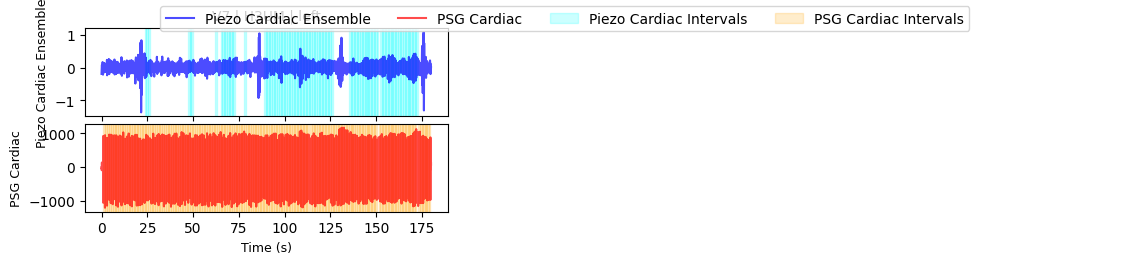

In [33]:
time_ranges_dict = {
}

plot_signal_comparison(
    filtered_df=filtered_cardiac_interval_outliers_df,
    structured_data_df=structured_participant_data_df,
    time_ranges=time_ranges_dict,
    margin_top=0.93,
)


In [34]:
cardiac_interval_outliers_df = structured_participant_data_df[["id", "mattress", "position", "pel_cardiac_ensemble_interval_matching"]]
cardiac_interval_outliers_df = cardiac_interval_outliers_df.sort_values(by="pel_cardiac_ensemble_interval_matching", ascending=True)

filtered_cardiac_interval_outliers_df = cardiac_interval_outliers_df[cardiac_interval_outliers_df["pel_cardiac_ensemble_interval_matching"] < 50]
filtered_cardiac_interval_outliers_df.head(15)

,id,mattress,position,pel_cardiac_ensemble_interval_matching
102,V7,H3UM,left,19.796954


## Interval Matching Plot

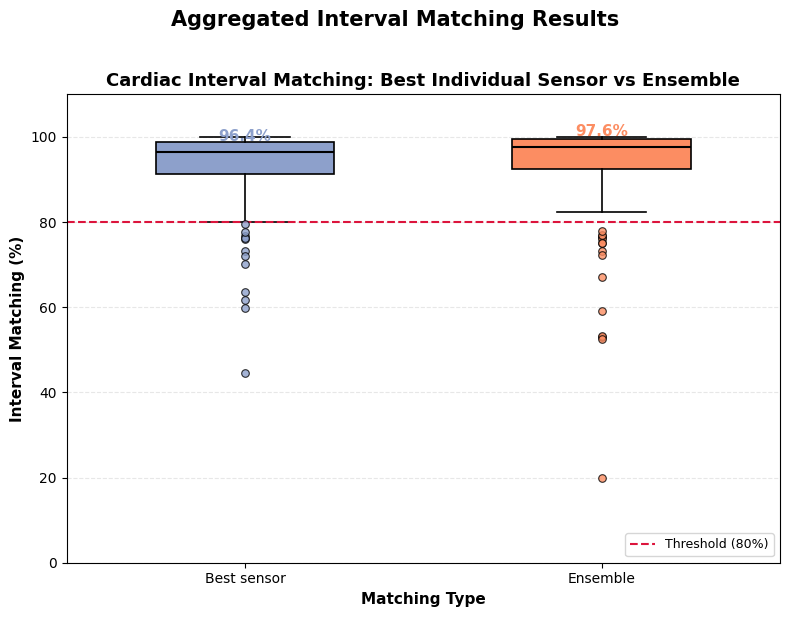


SUMMARY TABLE: Cardiac Interval Matching Results (Median [IQR])

Cardiac Interval Matching:
--------------------------------------------------
  Best sensor   : median= 96.4%  [Q1= 91.2%, Q3= 98.7%]  IQR=7.5 pp  (n=139)
                  outliers outside 1.5×IQR fences: 12/139 recordings (8.6%)
  Ensemble      : median= 97.6%  [Q1= 92.6%, Q3= 99.5%]  IQR=6.9 pp  (n=139)
                  outliers outside 1.5×IQR fences: 15/139 recordings (10.8%)

Average number of sensors above 80% per recording:
  mean = 5.0 / 16
  median = 5.0 / 16

Per-recording delta (Ensemble - Best sensor):
--------------------------------------------------
  median delta = +0.55 pp
  mean delta   = -0.01 pp
  std delta    = 8.14 pp
  Ensemble strictly better : 74/139 recordings (53.2%)
  Equal                    : 14/139 recordings
  Best sensor strictly better : 51/139 recordings (36.7%)


Raw summary data:
    Signal Matching_Type  Median (%)  Q1 (%)  Q3 (%)  IQR (pp)  Mean (%)  \
0  Cardiac   Best sensor    

In [35]:
def plot_matching_aggregated_subplots(df: pd.DataFrame, threshold: float, print_summary=True):
    """Compare ensemble fusion vs the best individual sensor (per recording).

    For each recording, the 'Best individual sensor' value is the maximum
    matching score across the 16 sensors. The 'Ensemble' value is the
    quality-weighted multi-sensor estimate.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    summary_data = []

    sensor_matchings_col = "pel_cardiac_sensor_interval_matchings"
    ensemble_matching_col = "pel_cardiac_ensemble_interval_matching"

    # Best individual sensor per recording
    best_sensor_series = df[sensor_matchings_col].apply(
        lambda lst: float(np.max(lst)) if len(lst) > 0 else np.nan
    )
    ensemble_series = pd.to_numeric(df[ensemble_matching_col], errors="coerce")

    best_df = pd.DataFrame({"matching_type": "Best sensor", "value": best_sensor_series})
    ensemble_df = pd.DataFrame({"matching_type": "Ensemble", "value": ensemble_series})
    plot_df = pd.concat([best_df, ensemble_df], ignore_index=True)
    plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")

    matching_types = ["Best sensor", "Ensemble"]
    colors = [REGULAR_COLOR, QUALITY_COLOR]

    box_data = []
    for matching_type in matching_types:
        type_data = plot_df[plot_df["matching_type"] == matching_type]["value"].dropna()
        box_data.append(type_data.values)
        q1 = np.percentile(type_data.values, 25)
        q3 = np.percentile(type_data.values, 75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        n_outliers = int(((type_data.values < lower_fence) | (type_data.values > upper_fence)).sum())
        summary_data.append({
            "Signal": "Cardiac",
            "Matching_Type": matching_type,
            "Median (%)": type_data.median(),
            "Q1 (%)": q1,
            "Q3 (%)": q3,
            "IQR (pp)": iqr,
            "Mean (%)": type_data.mean(),
            "Std (%)": type_data.std(),
            "Count": len(type_data),
            "N_outliers": n_outliers,
        })

    bp = ax.boxplot(
        box_data,
        positions=range(len(matching_types)),
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)

    for i, (data, color) in enumerate(zip(box_data, colors)):
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = data[(data < lower) | (data > upper)]
        ax.scatter(
            np.full_like(outliers, i), outliers,
            color=color, edgecolors="black", linewidth=0.8,
            zorder=5, s=30, alpha=0.8,
        )

    for i, data in enumerate(box_data):
        median_val = np.median(data)
        ax.text(i, median_val + 2, f"{median_val:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold", color=colors[i])

    if threshold is not None:
        ax.axhline(y=threshold, color="crimson", linestyle="--", linewidth=1.5,
                   label=f"Threshold ({threshold}%)")

    ax.set_title("Cardiac Interval Matching: Best Individual Sensor vs Ensemble", fontsize=13, fontweight="bold")
    ax.set_ylabel("Interval Matching (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Matching Type", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(matching_types)))
    ax.set_xticklabels(matching_types, fontsize=10)
    ax.set_ylim(0, 110)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    if threshold is not None:
        ax.legend(loc="lower right", fontsize=9)

    plt.suptitle("Aggregated Interval Matching Results", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_data)

    # Per-recording delta (Ensemble - Best sensor)
    delta = (ensemble_series - best_sensor_series).dropna()
    delta_positive = (delta > 0).sum()
    delta_zero = (delta == 0).sum()
    delta_negative = (delta < 0).sum()

    # Average number of sensors above 80% per recording
    n_above_80_per_recording = df[sensor_matchings_col].apply(
        lambda lst: int(np.sum(np.array(lst) > 80)) if len(lst) > 0 else 0
    )

    if print_summary:
        print("\n" + "=" * 80)
        print("SUMMARY TABLE: Cardiac Interval Matching Results (Median [IQR])")
        print("=" * 80)
        print("\nCardiac Interval Matching:")
        print("-" * 50)
        for matching_type in matching_types:
            row = summary_df[(summary_df["Signal"] == "Cardiac") &
                             (summary_df["Matching_Type"] == matching_type)]
            if not row.empty:
                median_val = row["Median (%)"].values[0]
                q1_val = row["Q1 (%)"].values[0]
                q3_val = row["Q3 (%)"].values[0]
                iqr_val = row["IQR (pp)"].values[0]
                count = row["Count"].values[0]
                n_out = row["N_outliers"].values[0]
                print(f"  {matching_type:14}: median={median_val:5.1f}%  [Q1={q1_val:5.1f}%, Q3={q3_val:5.1f}%]  IQR={iqr_val:.1f} pp  (n={count})")
                print(f"  {'':14}  outliers outside 1.5\u00d7IQR fences: {n_out}/{count} recordings ({100*n_out/count:.1f}%)")

        print(f"\nAverage number of sensors above 80% per recording:")
        print(f"  mean = {n_above_80_per_recording.mean():.1f} / 16")
        print(f"  median = {np.median(n_above_80_per_recording):.1f} / 16")

        print("\nPer-recording delta (Ensemble - Best sensor):")
        print("-" * 50)
        print(f"  median delta = {delta.median():+.02f} pp")
        print(f"  mean delta   = {delta.mean():+.2f} pp")
        print(f"  std delta    = {delta.std():.2f} pp")
        print(f"  Ensemble strictly better : {delta_positive}/{len(delta)} recordings ({100*delta_positive/len(delta):.1f}%)")
        print(f"  Equal                    : {delta_zero}/{len(delta)} recordings")
        print(f"  Best sensor strictly better : {delta_negative}/{len(delta)} recordings ({100*delta_negative/len(delta):.1f}%)")
        print("\n" + "=" * 80)

    return summary_df

summary_table = plot_matching_aggregated_subplots(
    structured_participant_data_df,
    threshold=80,
    print_summary=True
)

print("\nRaw summary data:")
print(summary_table.round(2))

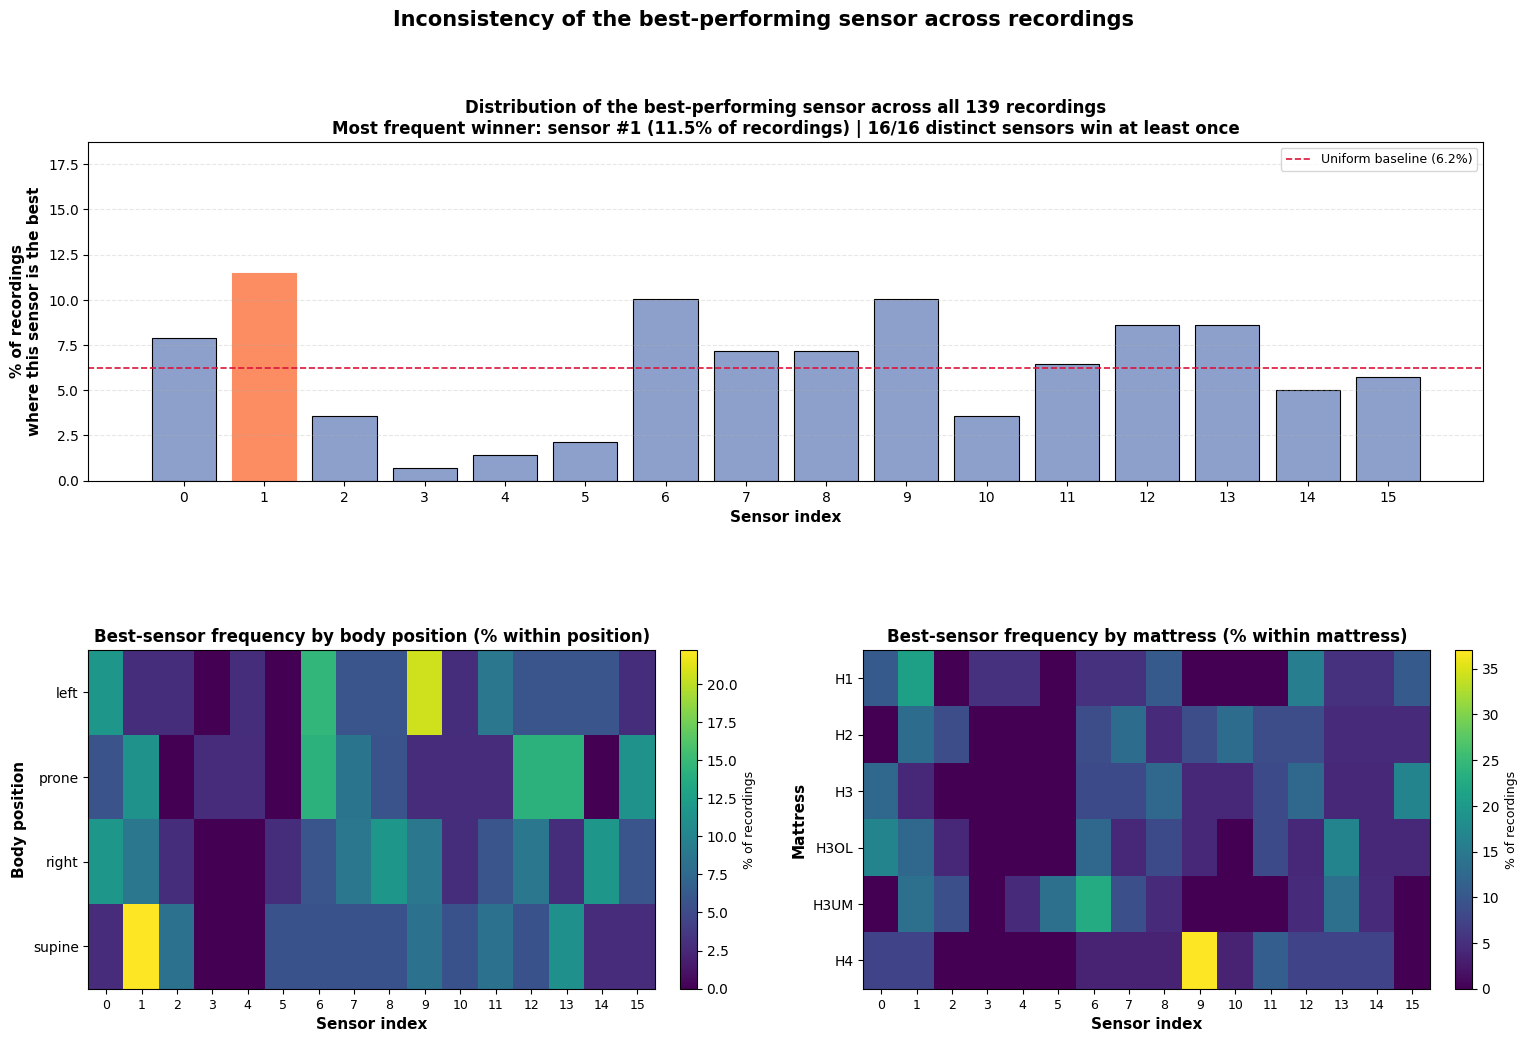


BEST-SENSOR INCONSISTENCY ANALYSIS
Total recordings analyzed: 139
Number of sensors: 16
Number of distinct sensors that win at least once: 16/16
Most frequent winner: sensor #1 (11.5% of recordings)
Uniform baseline (if no sensor were preferred): 6.2%

Per-sensor win counts (overall):
    sensor    count        %
         0       11     7.9%
         1       16    11.5%
         2        5     3.6%
         3        1     0.7%
         4        2     1.4%
         5        3     2.2%
         6       14    10.1%
         7       10     7.2%
         8       10     7.2%
         9       14    10.1%
        10        5     3.6%
        11        9     6.5%
        12       12     8.6%
        13       12     8.6%
        14        7     5.0%
        15        8     5.8%

Within (mattress, position) stability:
  Average # of distinct best-sensor winners per (mattress, position) cell
  (computed over 24 (mattress, position) cells with >= 2 recordings)
  mean # distinct best sensors per ce

In [36]:
def plot_best_sensor_inconsistency(df: pd.DataFrame):
    """Show that the index of the best-performing sensor is not consistent across recordings.

    Three panels:
      1. Frequency of being the best sensor (across all recordings).
      2. Frequency of being the best sensor, broken down by body position.
      3. Frequency of being the best sensor, broken down by mattress.

    A flat distribution means the "best sensor" depends on the recording, so
    selecting one sensor a priori would not be a viable strategy.
    """
    sensor_matchings_col = "pel_cardiac_sensor_interval_matchings"

    rows = df[sensor_matchings_col].apply(
        lambda lst: int(np.argmax(lst)) if len(lst) > 0 else -1
    )
    df_local = df.copy()
    df_local["best_sensor_idx"] = rows
    df_local = df_local[df_local["best_sensor_idx"] >= 0]

    n_sensors = int(df_local[sensor_matchings_col].apply(len).max())
    sensor_indices = list(range(n_sensors))

    counts = df_local["best_sensor_idx"].value_counts().reindex(sensor_indices, fill_value=0)
    pct = 100.0 * counts / counts.sum()

    most_freq_pct = pct.max()
    most_freq_idx = int(pct.idxmax())
    n_distinct_winners = int((counts > 0).sum())

    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.25, height_ratios=[1, 1])

    # Panel 1: overall
    ax_overall = fig.add_subplot(gs[0, :])
    bars = ax_overall.bar(sensor_indices, pct.values, color=REGULAR_COLOR, edgecolor="black", linewidth=0.8)
    bars[most_freq_idx].set_color(QUALITY_COLOR)
    ax_overall.axhline(100.0 / n_sensors, color="crimson", linestyle="--", linewidth=1.2,
                       label=f"Uniform baseline ({100.0/n_sensors:.1f}%)")
    ax_overall.set_xticks(sensor_indices)
    ax_overall.set_xlabel("Sensor index", fontsize=11, fontweight="bold")
    ax_overall.set_ylabel("% of recordings\nwhere this sensor is the best", fontsize=11, fontweight="bold")
    ax_overall.set_title(
        f"Distribution of the best-performing sensor across all {len(df_local)} recordings\n"
        f"Most frequent winner: sensor #{most_freq_idx} ({most_freq_pct:.1f}% of recordings) | "
        f"{n_distinct_winners}/{n_sensors} distinct sensors win at least once",
        fontsize=12, fontweight="bold",
    )
    ax_overall.grid(axis="y", alpha=0.3, linestyle="--")
    ax_overall.legend(loc="upper right", fontsize=9)
    ax_overall.set_ylim(0, max(100.0 / n_sensors * 3, pct.max() * 1.2))

    # Panel 2: by body position
    ax_pos = fig.add_subplot(gs[1, 0])
    positions = sorted(df_local["position"].dropna().unique().tolist())
    pos_matrix = np.zeros((len(positions), n_sensors))
    for i, pos in enumerate(positions):
        sub = df_local[df_local["position"] == pos]["best_sensor_idx"]
        if len(sub) > 0:
            c = sub.value_counts().reindex(sensor_indices, fill_value=0)
            pos_matrix[i] = 100.0 * c.values / c.sum()
    im = ax_pos.imshow(pos_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=max(pos_matrix.max(), 100.0 / n_sensors * 2))
    ax_pos.set_xticks(sensor_indices)
    ax_pos.set_xticklabels(sensor_indices, fontsize=9)
    ax_pos.set_yticks(range(len(positions)))
    ax_pos.set_yticklabels(positions, fontsize=10)
    ax_pos.set_xlabel("Sensor index", fontsize=11, fontweight="bold")
    ax_pos.set_ylabel("Body position", fontsize=11, fontweight="bold")
    ax_pos.set_title("Best-sensor frequency by body position (% within position)", fontsize=12, fontweight="bold")
    cbar = plt.colorbar(im, ax=ax_pos, fraction=0.046, pad=0.04)
    cbar.set_label("% of recordings", fontsize=9)

    # Panel 3: by mattress
    ax_mat = fig.add_subplot(gs[1, 1])
    mattresses = sorted(df_local["mattress"].dropna().unique().tolist())
    mat_matrix = np.zeros((len(mattresses), n_sensors))
    for i, m in enumerate(mattresses):
        sub = df_local[df_local["mattress"] == m]["best_sensor_idx"]
        if len(sub) > 0:
            c = sub.value_counts().reindex(sensor_indices, fill_value=0)
            mat_matrix[i] = 100.0 * c.values / c.sum()
    im2 = ax_mat.imshow(mat_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=max(mat_matrix.max(), 100.0 / n_sensors * 2))
    ax_mat.set_xticks(sensor_indices)
    ax_mat.set_xticklabels(sensor_indices, fontsize=9)
    ax_mat.set_yticks(range(len(mattresses)))
    ax_mat.set_yticklabels(mattresses, fontsize=10)
    ax_mat.set_xlabel("Sensor index", fontsize=11, fontweight="bold")
    ax_mat.set_ylabel("Mattress", fontsize=11, fontweight="bold")
    ax_mat.set_title("Best-sensor frequency by mattress (% within mattress)", fontsize=12, fontweight="bold")
    cbar2 = plt.colorbar(im2, ax=ax_mat, fraction=0.046, pad=0.04)
    cbar2.set_label("% of recordings", fontsize=9)

    plt.suptitle(
        "Inconsistency of the best-performing sensor across recordings",
        fontsize=15, fontweight="bold", y=1.00,
    )
    plt.show()

    # Printed summary
    print()
    print("=" * 80)
    print("BEST-SENSOR INCONSISTENCY ANALYSIS")
    print("=" * 80)
    print(f"Total recordings analyzed: {len(df_local)}")
    print(f"Number of sensors: {n_sensors}")
    print(f"Number of distinct sensors that win at least once: {n_distinct_winners}/{n_sensors}")
    print(f"Most frequent winner: sensor #{most_freq_idx} ({most_freq_pct:.1f}% of recordings)")
    print(f"Uniform baseline (if no sensor were preferred): {100.0/n_sensors:.1f}%")

    print("\nPer-sensor win counts (overall):")
    print(f"  {'sensor':>8} {'count':>8} {'%':>8}")
    for idx in sensor_indices:
        print(f"  {idx:>8} {int(counts[idx]):>8} {pct[idx]:>7.1f}%")

    # Stability per (mattress, position): does the same sensor win across repeats?
    print("\nWithin (mattress, position) stability:")
    print(f"  Average # of distinct best-sensor winners per (mattress, position) cell")
    cell_stats = df_local.groupby(["mattress", "position"])["best_sensor_idx"].agg(
        n="count", n_distinct=lambda s: s.nunique()
    )
    cell_stats = cell_stats[cell_stats["n"] >= 2]
    if len(cell_stats) > 0:
        avg_distinct = cell_stats["n_distinct"].mean()
        avg_n = cell_stats["n"].mean()
        print(f"  (computed over {len(cell_stats)} (mattress, position) cells with >= 2 recordings)")
        print(f"  mean # distinct best sensors per cell = {avg_distinct:.2f}")
        print(f"  mean # recordings per cell           = {avg_n:.2f}")
    else:
        print("  Not enough repeats per (mattress, position) cell to assess stability.")
    print("=" * 80)


plot_best_sensor_inconsistency(structured_participant_data_df)


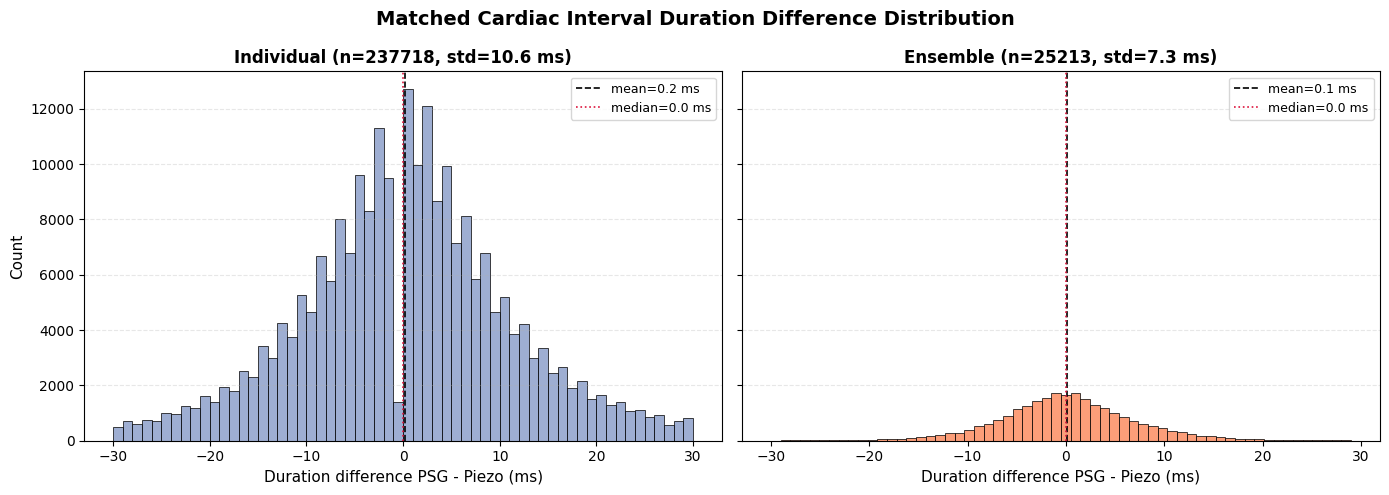

Individual: mean=0.21 ms, std=10.62 ms, median=0.00 ms, n=237718
Ensemble:   mean=0.13 ms, std=7.29 ms, median=0.00 ms, n=25213


In [37]:
def plot_matched_interval_difference_distribution(df: pd.DataFrame):
    """Plot distribution of duration differences (in ms) between matched PSG and Piezo cardiac intervals."""
    sensor_diffs_ms = []
    for matches_list in df["pel_cardiac_sensor_interval_matches_list"]:
        for sensor_matches in matches_list:
            for m in sensor_matches:
                diff_ms = (m["rate1"].duration_s - m["rate2"].duration_s) * 1000.0
                sensor_diffs_ms.append(diff_ms)

    ensemble_diffs_ms = []
    for matches in df["pel_cardiac_ensemble_interval_matches"]:
        for m in matches:
            diff_ms = (m["rate1"].duration_s - m["rate2"].duration_s) * 1000.0
            ensemble_diffs_ms.append(diff_ms)

    sensor_diffs_ms = np.array(sensor_diffs_ms)
    ensemble_diffs_ms = np.array(ensemble_diffs_ms)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, data, label, color in zip(
        axes,
        [sensor_diffs_ms, ensemble_diffs_ms],
        ["Individual", "Ensemble"],
        [REGULAR_COLOR, QUALITY_COLOR],
    ):
        ax.hist(data, bins=60, color=color, edgecolor="black", linewidth=0.6, alpha=0.85)
        mean_v = np.mean(data)
        std_v = np.std(data)
        median_v = np.median(data)
        ax.axvline(mean_v, color="black", linestyle="--", linewidth=1.2, label=f"mean={mean_v:.1f} ms")
        ax.axvline(median_v, color="crimson", linestyle=":", linewidth=1.2, label=f"median={median_v:.1f} ms")
        ax.set_title(f"{label} (n={len(data)}, std={std_v:.1f} ms)", fontsize=12, fontweight="bold")
        ax.set_xlabel("Duration difference PSG - Piezo (ms)", fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.legend(loc="upper right", fontsize=9)

    axes[0].set_ylabel("Count", fontsize=11)
    plt.suptitle("Matched Cardiac Interval Duration Difference Distribution", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Individual: mean={np.mean(sensor_diffs_ms):.2f} ms, std={np.std(sensor_diffs_ms):.2f} ms, median={np.median(sensor_diffs_ms):.2f} ms, n={len(sensor_diffs_ms)}")
    print(f"Ensemble:   mean={np.mean(ensemble_diffs_ms):.2f} ms, std={np.std(ensemble_diffs_ms):.2f} ms, median={np.median(ensemble_diffs_ms):.2f} ms, n={len(ensemble_diffs_ms)}")


plot_matched_interval_difference_distribution(structured_participant_data_df)


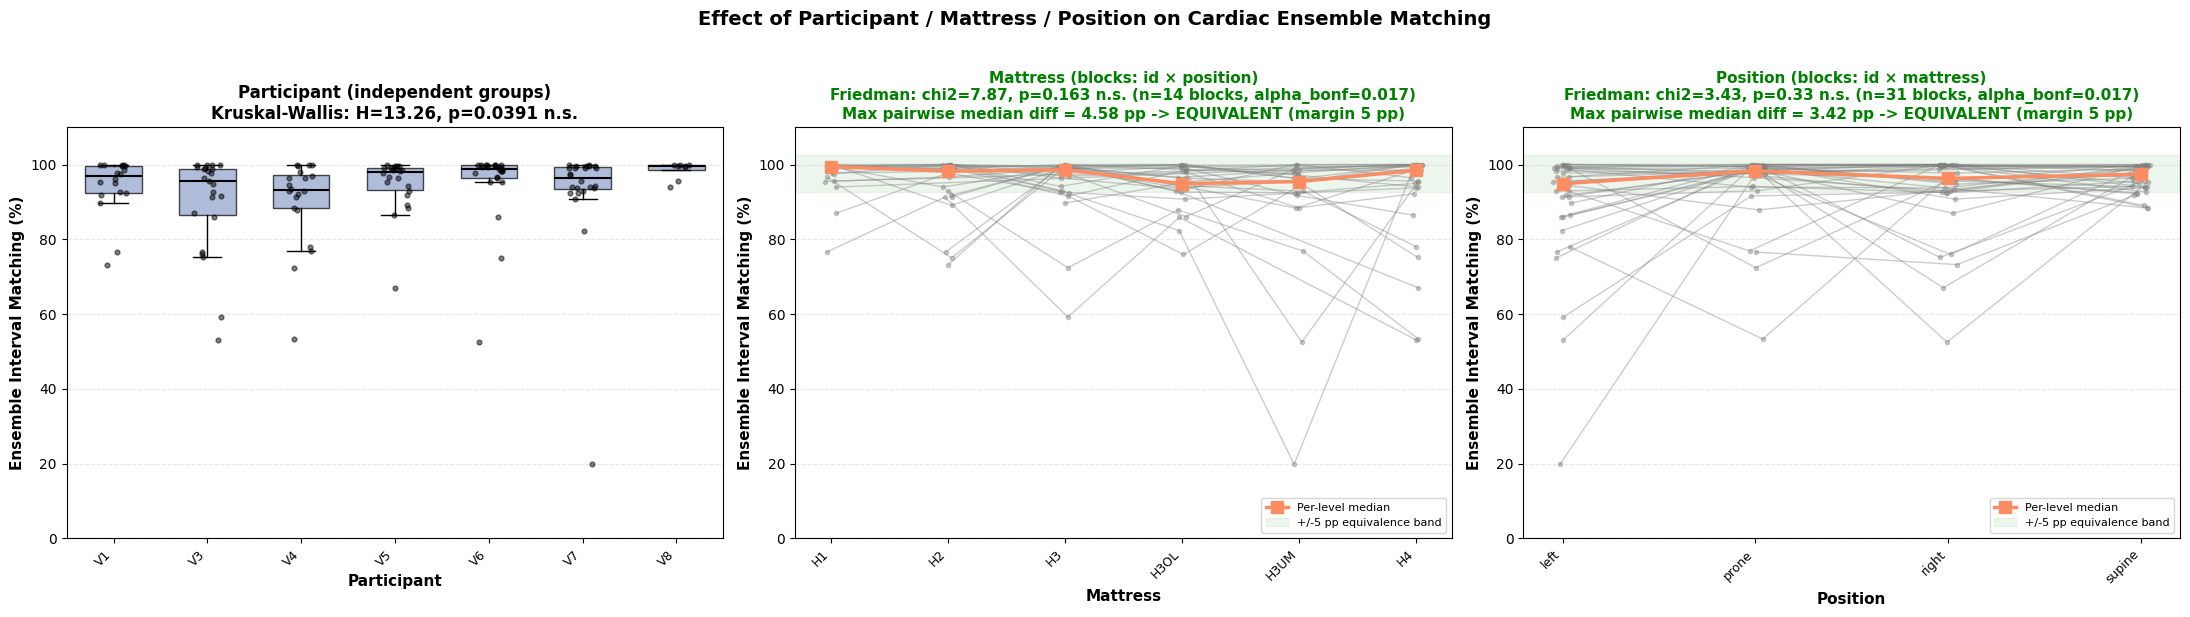


################################################################################
STATISTICAL RESULTS
  alpha (raw) = 0.05,  alpha (Bonferroni, m=3) = 0.0167
  Equivalence margin = +/-5 percentage points
################################################################################

Factor: participant
--------------------------------------------------------------------------------
Test: Kruskal-Wallis
  H = 13.2579
  p-value = 0.0391184
  n total = 139  (across 7 groups)
  Raw alpha=0.05:        significant (p < 0.05)
  Bonferroni alpha=0.0167: n.s. (p >= 0.0167)
  Max pairwise median diff = 6.35 pp
  Per-level summary:
    level                    n     median       mean        std
    V1                      18      96.88      94.21       7.76
    V3                      23      95.54      89.87      13.30
    V4                      20      93.19      90.05      11.74
    V5                      22      97.97      94.81       7.39
    V6                      24      98.89      95

In [38]:
from scipy.stats import kruskal, friedmanchisquare
from itertools import combinations

EQUIVALENCE_MARGIN_PP = 5.0
N_FACTOR_TESTS = 3
ALPHA = 0.05
ALPHA_BONF = ALPHA / N_FACTOR_TESTS


def _participant_factor_panel(ax, df, value_col):
    """Kruskal-Wallis across participants (independent groups)."""
    grouped = list(df.groupby("id"))
    group_labels = [str(name) for name, _ in grouped]
    groups = [g[value_col].dropna().values for _, g in grouped]

    nonempty = [(lbl, vals) for lbl, vals in zip(group_labels, groups) if len(vals) > 0]
    group_labels = [lbl for lbl, _ in nonempty]
    groups = [vals for _, vals in nonempty]

    if len(groups) >= 2:
        h_stat, p_value = kruskal(*groups)
    else:
        h_stat, p_value = float("nan"), float("nan")

    positions = np.arange(len(groups))
    bp = ax.boxplot(
        groups,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(REGULAR_COLOR)
        patch.set_edgecolor("black")
        patch.set_alpha(0.7)

    rng = np.random.default_rng(0)
    for pos, vals in zip(positions, groups):
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(pos + jitter, vals, color="black", s=12, alpha=0.5, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Ensemble Interval Matching (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Participant", fontsize=11, fontweight="bold")
    sig = "n.s." if (not np.isnan(p_value) and p_value >= ALPHA_BONF) else "*"
    ax.set_title(
        f"Participant (independent groups)\nKruskal-Wallis: H={h_stat:.2f}, p={p_value:.3g} {sig}",
        fontsize=12,
        fontweight="bold",
    )
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    medians = [float(np.median(v)) for v in groups]
    max_diff_pp = float(max(medians) - min(medians)) if len(medians) >= 2 else float("nan")

    per_group = []
    for lbl, vals in zip(group_labels, groups):
        per_group.append({
            "level": lbl,
            "n": len(vals),
            "median": float(np.median(vals)),
            "mean": float(np.mean(vals)),
            "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else float("nan"),
        })

    return {
        "factor": "participant",
        "test": "Kruskal-Wallis",
        "statistic_name": "H",
        "statistic": float(h_stat),
        "p_value": float(p_value),
        "n_groups": len(groups),
        "n_total": int(sum(len(v) for v in groups)),
        "max_pairwise_median_diff_pp": max_diff_pp,
        "per_group": per_group,
    }


def _within_participant_panel(ax, df, factor, factor_label, value_col, block_factors):
    """Friedman test using composite blocks (no pre-aggregation).

    Each unique combination of (block_factors) defines one block row.
    Each block must have exactly one observation per factor level.
    Incomplete blocks (missing any level) are dropped.

    Parameters
    ----------
    block_factors : list[str]
        Columns that together define the repeated-measures block.
        For factor='position', pass block_factors=['id', 'mattress'].
        For factor='mattress', pass block_factors=['id', 'position'].
    """
    levels = sorted(df[factor].dropna().unique().tolist())
    level_to_pos = {lvl: i for i, lvl in enumerate(levels)}

    # Build wide table: one row per unique block, one column per factor level
    wide = (
        df[block_factors + [factor, value_col]]
        .dropna(subset=[factor, value_col])
        .groupby(block_factors + [factor])[value_col]
        .first()          # unique tuple → only one value per cell
        .unstack(factor)  # columns = factor levels
    )
    complete = wide.dropna(how="any")  # keep only blocks with all levels present
    n_complete = len(complete)

    if n_complete >= 2 and len(levels) >= 2:
        try:
            stat, p_value = friedmanchisquare(*[complete[lvl].values for lvl in levels])
        except ValueError:
            stat, p_value = float("nan"), float("nan")
    else:
        stat, p_value = float("nan"), float("nan")

    # ── Spaghetti plot: one line per block ──────────────────────────────────
    rng = np.random.default_rng(1)
    for _, row in wide.iterrows():
        xs, ys = [], []
        for lvl in levels:
            v = row.get(lvl)
            if pd.notna(v):
                xs.append(level_to_pos[lvl])
                ys.append(v)
        if len(xs) >= 1:
            jitter = rng.uniform(-0.05, 0.05, size=len(xs))
            ax.plot(np.array(xs) + jitter, ys, color="gray", alpha=0.4,
                    linewidth=1, marker="o", markersize=3)

    medians = [np.nanmedian(wide[lvl].values) if lvl in wide.columns else np.nan for lvl in levels]
    ax.plot(range(len(levels)), medians, color=QUALITY_COLOR, linewidth=2.5,
            marker="s", markersize=8, label="Per-level median", zorder=5)

    # ── Descriptive equivalence ─────────────────────────────────────────────
    valid_medians = [m for m in medians if not np.isnan(m)]
    max_diff_pp = float(max(valid_medians) - min(valid_medians)) if len(valid_medians) >= 2 else float("nan")
    equivalent = (not np.isnan(max_diff_pp)) and (max_diff_pp <= EQUIVALENCE_MARGIN_PP)
    eq_str = "EQUIVALENT" if equivalent else "NOT EQUIVALENT"
    eq_color = "green" if equivalent else "crimson"

    overall_median = float(np.nanmedian([v for col in wide.columns for v in wide[col].dropna().values]))
    ax.axhspan(
        overall_median - EQUIVALENCE_MARGIN_PP,
        overall_median + EQUIVALENCE_MARGIN_PP,
        color="green", alpha=0.07,
        label=f"+/-{EQUIVALENCE_MARGIN_PP:.0f} pp equivalence band",
    )

    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels], rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Ensemble Interval Matching (%)", fontsize=11, fontweight="bold")
    ax.set_xlabel(factor_label, fontsize=11, fontweight="bold")
    sig = "n.s." if (not np.isnan(p_value) and p_value >= ALPHA_BONF) else "*"
    block_desc = " × ".join(block_factors)
    title = (
        f"{factor_label} (blocks: {block_desc})\n"
        f"Friedman: chi2={stat:.2f}, p={p_value:.3g} {sig} (n={n_complete} blocks, alpha_bonf={ALPHA_BONF:.3f})\n"
        f"Max pairwise median diff = {max_diff_pp:.2f} pp -> {eq_str} (margin {EQUIVALENCE_MARGIN_PP:.0f} pp)"
    )
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=eq_color if equivalent else "black")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(loc="lower right", fontsize=8)

    per_group = []
    for lvl in levels:
        vals = wide[lvl].dropna().values if lvl in wide.columns else np.array([])
        per_group.append({
            "level": str(lvl),
            "n": len(vals),
            "median": float(np.median(vals)) if len(vals) else float("nan"),
            "mean": float(np.mean(vals)) if len(vals) else float("nan"),
            "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else float("nan"),
        })

    pairwise = []
    for (a, b) in combinations(range(len(levels)), 2):
        if not (np.isnan(medians[a]) or np.isnan(medians[b])):
            pairwise.append({
                "pair": f"{levels[a]} vs {levels[b]}",
                "diff_pp": float(medians[a] - medians[b]),
                "abs_diff_pp": float(abs(medians[a] - medians[b])),
            })

    return {
        "factor": factor,
        "test": "Friedman",
        "statistic_name": "chi2",
        "statistic": float(stat),
        "p_value": float(p_value),
        "n_groups": len(levels),
        "n_complete_cases": int(n_complete),
        "block_factors": block_factors,
        "max_pairwise_median_diff_pp": max_diff_pp,
        "equivalent_within_margin": bool(equivalent),
        "equivalence_margin_pp": EQUIVALENCE_MARGIN_PP,
        "per_group": per_group,
        "pairwise_median_diffs": pairwise,
    }


def _print_factor_result(result):
    print()
    print("=" * 80)
    print(f"Factor: {result['factor']}")
    print("-" * 80)
    print(f"Test: {result['test']}")
    print(f"  {result['statistic_name']} = {result['statistic']:.4f}")
    print(f"  p-value = {result['p_value']:.6g}")

    if "block_factors" in result:
        print(f"  Blocks defined by: {' × '.join(result['block_factors'])}")

    if "n_complete_cases" in result:
        print(f"  n complete blocks = {result['n_complete_cases']}  (across {result['n_groups']} levels)")
    else:
        print(f"  n total = {result['n_total']}  (across {result['n_groups']} groups)")

    sig_raw = "n.s." if result["p_value"] >= ALPHA else "significant"
    sig_bonf = "n.s." if result["p_value"] >= ALPHA_BONF else "significant"
    print(f"  Raw alpha=0.05:        {sig_raw} (p {'>=' if result['p_value'] >= ALPHA else '<'} {ALPHA})")
    print(f"  Bonferroni alpha={ALPHA_BONF:.4f}: {sig_bonf} (p {'>=' if result['p_value'] >= ALPHA_BONF else '<'} {ALPHA_BONF:.4f})")

    if "equivalent_within_margin" in result:
        eq = "EQUIVALENT" if result["equivalent_within_margin"] else "NOT EQUIVALENT"
        print(f"  Descriptive equivalence ({EQUIVALENCE_MARGIN_PP:.0f} pp margin):")
        print(f"    Max pairwise median diff = {result['max_pairwise_median_diff_pp']:.2f} pp -> {eq}")
    elif not np.isnan(result.get("max_pairwise_median_diff_pp", float("nan"))):
        print(f"  Max pairwise median diff = {result['max_pairwise_median_diff_pp']:.2f} pp")

    print(f"  Per-level summary:")
    print(f"    {'level':<20} {'n':>5} {'median':>10} {'mean':>10} {'std':>10}")
    for g in result["per_group"]:
        std_str = f"{g['std']:.2f}" if not np.isnan(g['std']) else "  -"
        print(f"    {g['level']:<20} {g['n']:>5} {g['median']:>10.2f} {g['mean']:>10.2f} {std_str:>10}")

    if "pairwise_median_diffs" in result and result["pairwise_median_diffs"]:
        print(f"  Pairwise median differences (sorted by absolute value):")
        for pw in sorted(result["pairwise_median_diffs"], key=lambda x: -x["abs_diff_pp"]):
            print(f"    {pw['pair']:<30} {pw['diff_pp']:+8.2f} pp")


def plot_matching_by_factor(df: pd.DataFrame, value_col: str = "pel_cardiac_ensemble_interval_matching"):
    """Visualize ensemble matching score by participant / mattress / position.

    Statistical strategy:
      - Participant: Kruskal-Wallis (independent groups).
      - Mattress: Friedman on blocks defined by (id × position).
        Each (participant, position) pair is one block; the factor level is mattress.
      - Position: Friedman on blocks defined by (id × mattress).
        Each (participant, mattress) pair is one block; the factor level is position.
      - This avoids pre-aggregation and maximises the number of complete blocks.
      - Bonferroni correction across the 3 factor tests.
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    results = []
    results.append(_participant_factor_panel(axes[0], df, value_col))
    results.append(_within_participant_panel(axes[1], df, "mattress", "Mattress", value_col,
                                             block_factors=["id", "position"]))
    results.append(_within_participant_panel(axes[2], df, "position", "Position", value_col,
                                             block_factors=["id", "mattress"]))

    plt.suptitle(
        "Effect of Participant / Mattress / Position on Cardiac Ensemble Matching",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()

    print()
    print("#" * 80)
    print("STATISTICAL RESULTS")
    print(f"  alpha (raw) = {ALPHA},  alpha (Bonferroni, m={N_FACTOR_TESTS}) = {ALPHA_BONF:.4f}")
    print(f"  Equivalence margin = +/-{EQUIVALENCE_MARGIN_PP:.0f} percentage points")
    print("#" * 80)
    for r in results:
        _print_factor_result(r)
    print()
    print("#" * 80)
    print("Notes:")
    print(" - Participant: Kruskal-Wallis on independent groups.")
    print(" - Mattress: Friedman blocks = (participant × position) — no pre-aggregation.")
    print(" - Position: Friedman blocks = (participant × mattress) — no pre-aggregation.")
    print(" - Incomplete blocks (missing any factor level) are excluded from Friedman.")
    print(f" - 'Equivalent' means max pairwise median diff <= {EQUIVALENCE_MARGIN_PP:.0f} pp.")
    print(" - Bonferroni correction applied across the 3 factor tests.")
    print("#" * 80)

    return results


_factor_results = plot_matching_by_factor(structured_participant_data_df)